# Crazyflie log analysis: estimator drift + trajectory tracking comparison

这个 notebook 用来分析 Crazyflie log，例如 `install_test1_58.csv`。

它会做两件事：

1. 检查起飞/任务开始前 `stateX/stateY/stateVX/stateVY` 是否已经异常漂移；
2. 如果你有 tracking/reference trajectory CSV，直接和 log 里的 `stateX/stateY/yaw` 做对比，输出 tracking error。

支持的 reference trajectory 表格格式：

- `x_local, y_local, yaw_local`
- `x, y, yaw`
- `trajx, trajy`
- 如果 reference CSV 有 `time`, `t_s`, `time_s`, `timestamp` 这类时间列，会按时间插值；
- 如果没有时间列，会按轨迹点顺序重采样到 log 的长度。


In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# User settings
# =========================

# Flight log.
LOG_CSV_PATH = "data/installation_drone_logs/install_test1_79.csv"

# Optional: put your tracking/reference trajectory CSV here.
# Example:
# TRACK_CSV_PATH = "/mnt/data/next_drone_full_trajectory_landing_frame_20260619_123456.csv"
TRACK_CSV_PATH = "next_drone_full_trajectory_landing_frame_20260522_132342.csv"

# Output folder for figures.
OUTDIR = "crazyflie_tracking_analysis_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# If True, compare after subtracting the first state position.
# This is useful when estimator starts with a large global offset, e.g. stateX≈6.
COMPARE_START_ALIGNED = True

# Active-flight selection. The notebook will try mission_state first.
ACTIVE_MISSION_STATE_MIN = 1
ACTIVE_Z_MIN = 0.08


In [48]:
def strip_columns(df):
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    return out

def numeric_df(df):
    out = strip_columns(df)
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def make_time_column(df):
    df = df.copy()
    time_candidates = ["t_s", "time_s", "time", "timestamp", "timeTick"]
    found = None
    for c in time_candidates:
        if c in df.columns and df[c].notna().any():
            found = c
            break

    if found is None:
        df["t_s"] = np.arange(len(df)) * 0.02
        return df, "sample_index_assumed_50Hz"

    if found == "timeTick":
        # Crazyflie timeTick is usually ms.
        df["t_s"] = (df[found] - df[found].iloc[0]) / 1000.0
    else:
        df["t_s"] = df[found] - df[found].iloc[0]

    return df, found

def find_first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

def wrap_to_pi(angle):
    return (angle + np.pi) % (2*np.pi) - np.pi

def angle_diff(a, b):
    return wrap_to_pi(a - b)

def load_log(path):
    df = pd.read_csv(path)
    df = numeric_df(df)
    df, time_source = make_time_column(df)
    return df, time_source

def load_reference(path):
    ref = pd.read_csv(path)
    ref = numeric_df(ref)
    ref, time_source = make_time_column(ref)

    x_col = find_first_existing(ref.columns, ["x_local", "x", "trajx", "ref_x", "cmd_x"])
    y_col = find_first_existing(ref.columns, ["y_local", "y", "trajy", "ref_y", "cmd_y"])
    yaw_col = find_first_existing(ref.columns, ["yaw_local", "yaw", "ref_yaw", "cmd_yaw"])

    if x_col is None or y_col is None:
        raise RuntimeError(f"Cannot find x/y columns in reference CSV. Columns: {list(ref.columns)}")

    ref = ref[[c for c in ["t_s", x_col, y_col, yaw_col] if c is not None]].copy()
    ref = ref.rename(columns={x_col: "ref_x", y_col: "ref_y"})
    if yaw_col is not None:
        ref = ref.rename(columns={yaw_col: "ref_yaw"})
    else:
        ref["ref_yaw"] = np.nan

    # Drop invalid position rows.
    ref = ref[np.isfinite(ref["ref_x"]) & np.isfinite(ref["ref_y"])].reset_index(drop=True)

    return ref, time_source

log_df, log_time_source = load_log(LOG_CSV_PATH)

print("LOG_CSV_PATH:", LOG_CSV_PATH)
print("log shape:", log_df.shape)
print("log time source:", log_time_source)
print("log columns:")
for c in log_df.columns:
    print(" ", c)

display(log_df.head())


LOG_CSV_PATH: data/installation_drone_logs/install_test1_79.csv
log shape: (1191, 19)
log time source: timeTick
log columns:
  timeTick
  stateX
  stateY
  stateZ
  stateVX
  stateVY
  yaw
  noDynVx
  noDynVy
  noDynSpeed
  mission_state
  traj_index
  cmdA
  cmdB
  cmdHeight
  contact
  trajx
  trajy
  t_s


,timeTick,stateX,stateY,stateZ,stateVX,stateVY,yaw,noDynVx,noDynVy,noDynSpeed,mission_state,traj_index,cmdA,cmdB,cmdHeight,contact,trajx,trajy,t_s
0,7462,0.001172,-0.000222,0.004065,0.008300,0.002047,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
1,7482,0.000564,-0.000833,0.003984,0.003866,-0.001619,0.023450,0.020019,0.082364,0.084762,0.0,0.0,0.000356,-0.000019,0.3,0.0,0.0,0.0,0.02
2,7502,-0.000465,-0.000018,0.004765,-0.002455,0.003335,0.022942,0.020019,0.082364,0.084762,0.0,0.0,0.000356,-0.000019,0.3,0.0,0.0,0.0,0.04
3,7522,-0.000671,-0.000015,0.004776,-0.003133,0.003410,0.022744,-0.062285,0.041609,0.074905,0.0,0.0,-0.000465,-0.000018,0.3,0.0,0.0,0.0,0.06
4,7542,0.000352,-0.000827,0.004799,0.002829,-0.001435,0.021098,-0.062285,0.041609,0.074905,0.0,0.0,-0.000465,-0.000018,0.3,0.0,0.0,0.0,0.08


## 1. Basic log summary


In [49]:
cols_to_check = [
    "stateX", "stateY", "stateZ",
    "stateVX", "stateVY",
    "yaw",
    "noDynVx", "noDynVy", "noDynSpeed",
    "mission_state", "traj_index",
    "cmdA", "cmdB", "cmdHeight",
    "contact", "trajx", "trajy",
]
cols_to_check = [c for c in cols_to_check if c in log_df.columns]

print("duration [s]:", float(log_df["t_s"].iloc[-1] - log_df["t_s"].iloc[0]))
display(log_df[cols_to_check].agg(["min", "max", "mean", "std"]).T)

print("First 10 rows:")
display(log_df.head(10))

print("Last 10 rows:")
display(log_df.tail(10))


duration [s]: 23.8


,min,max,mean,std
stateX,-0.001409,0.333445,0.140744,0.107274
stateY,-0.042969,0.459611,0.101342,0.152982
stateZ,-0.002562,0.767912,0.156271,0.157501
stateVX,-0.271319,0.472959,0.004341,0.096921
stateVY,-0.419467,0.237662,0.021008,0.077132
yaw,-1.810176,151.716797,53.950935,59.310495
noDynVx,-8.338394,3.583533,0.030497,0.564753
noDynVy,-4.869090,3.997330,0.010471,0.402960
noDynSpeed,0.000000,8.370213,0.250274,0.647822
mission_state,0.000000,9.000000,3.050420,3.490101


First 10 rows:


,timeTick,stateX,stateY,stateZ,stateVX,stateVY,yaw,noDynVx,noDynVy,noDynSpeed,mission_state,traj_index,cmdA,cmdB,cmdHeight,contact,trajx,trajy,t_s
0,7462,0.001172,-0.000222,0.004065,0.008300,0.002047,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
1,7482,0.000564,-0.000833,0.003984,0.003866,-0.001619,0.023450,0.020019,0.082364,0.084762,0.0,0.0,0.000356,-0.000019,0.3,0.0,0.0,0.0,0.02
2,7502,-0.000465,-0.000018,0.004765,-0.002455,0.003335,0.022942,0.020019,0.082364,0.084762,0.0,0.0,0.000356,-0.000019,0.3,0.0,0.0,0.0,0.04
3,7522,-0.000671,-0.000015,0.004776,-0.003133,0.003410,0.022744,-0.062285,0.041609,0.074905,0.0,0.0,-0.000465,-0.000018,0.3,0.0,0.0,0.0,0.06
4,7542,0.000352,-0.000827,0.004799,0.002829,-0.001435,0.021098,-0.062285,0.041609,0.074905,0.0,0.0,-0.000465,-0.000018,0.3,0.0,0.0,0.0,0.08
5,7562,0.000566,-0.001030,0.004463,0.003527,-0.002454,0.020982,-0.062285,0.041609,0.074905,0.0,0.0,-0.000465,-0.000018,0.3,0.0,0.0,0.0,0.10
6,7582,0.000165,-0.000825,0.004450,0.001183,-0.001078,0.022114,0.082633,-0.000112,0.082633,0.0,0.0,0.001159,-0.000830,0.3,0.0,0.0,0.0,0.12
7,7602,0.000357,-0.000226,0.004251,0.002723,0.002123,0.022621,0.082633,-0.000112,0.082633,0.0,0.0,0.001159,-0.000830,0.3,0.0,0.0,0.0,0.14
8,7622,0.000159,-0.000825,0.004230,0.001208,-0.001748,0.022936,0.082310,-0.021253,0.085010,0.0,0.0,0.000357,-0.000226,0.3,0.0,0.0,0.0,0.16
9,7642,0.000749,-0.000823,0.004117,0.004669,-0.001723,0.023440,0.082310,-0.021253,0.085010,0.0,0.0,0.000357,-0.000226,0.3,0.0,0.0,0.0,0.18


Last 10 rows:


,timeTick,stateX,stateY,stateZ,stateVX,stateVY,yaw,noDynVx,noDynVy,noDynSpeed,mission_state,traj_index,cmdA,cmdB,cmdHeight,contact,trajx,trajy,t_s
1181,31082,0.277390,0.252374,0.000392,0.008331,0.026610,121.186455,-0.102476,-0.002829,0.102515,9.0,3.0,0.276797,0.251321,0.3,0.0,0.0,0.0,23.62
1182,31102,0.276586,0.252421,0.000297,0.004782,0.026014,120.985062,-0.102476,-0.002829,0.102515,9.0,3.0,0.276797,0.251321,0.3,0.0,0.0,0.0,23.64
1183,31122,0.277429,0.252609,0.000340,0.009847,0.025997,120.792274,0.044135,-0.003899,0.044307,9.0,3.0,0.276586,0.252421,0.3,0.0,0.0,0.0,23.66
1184,31142,0.277104,0.251636,0.000279,0.008196,0.019922,120.592369,0.044135,-0.003899,0.044307,9.0,3.0,0.276586,0.252421,0.3,0.0,0.0,0.0,23.68
1185,31162,0.277668,0.251941,0.000317,0.011703,0.021059,120.408798,0.044135,-0.003899,0.044307,9.0,3.0,0.276586,0.252421,0.3,0.0,0.0,0.0,23.70
1186,31182,0.276551,0.251564,0.000254,0.006356,0.018346,120.208908,0.001511,0.017498,0.017563,9.0,3.0,0.276894,0.251501,0.3,0.0,0.0,0.0,23.72
1187,31202,0.277395,0.252289,0.000289,0.011344,0.022292,120.021194,0.001511,0.017498,0.017563,9.0,3.0,0.276894,0.251501,0.3,0.0,0.0,0.0,23.74
1188,31222,0.276888,0.250775,0.000243,0.009518,0.013613,119.814232,0.001401,-0.086969,0.086980,9.0,3.0,0.277395,0.252289,0.3,0.0,0.0,0.0,23.76
1189,31242,0.277429,0.252088,0.000278,0.012360,0.020726,119.632202,0.001401,-0.086969,0.086980,9.0,3.0,0.277395,0.252289,0.3,0.0,0.0,0.0,23.78
1190,31262,0.277037,0.252838,0.000359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.80


## 2. Initial drift diagnosis

重点看任务还没开始、或者前 5 秒时，`stateX/stateY/stateVX/stateVY` 是否已经很大。

如果 `stateZ` 还接近地面，但 `stateX/stateY` 已经是几米，并且速度非零，通常说明：

- estimator 没有在起飞前 reset；
- Flowdeck 积分已经在地面/搬运过程中漂了；
- 或者自定义 estimator/noDyn 状态没有清零。


In [50]:
def segment_initial(df):
    # Prefer mission_state==initial value.
    if "mission_state" in df.columns and df["mission_state"].notna().any():
        initial_state = df["mission_state"].dropna().iloc[0]
        seg = df[df["mission_state"] == initial_state].copy()
        if len(seg) >= 5:
            return seg, f"mission_state == {initial_state}"
    return df[df["t_s"] <= 5.0].copy(), "first 5 seconds"

def summarize_segment(seg, name):
    row = {"segment": name, "n": len(seg)}
    if len(seg) == 0:
        return row
    row["t0"] = float(seg["t_s"].iloc[0])
    row["t1"] = float(seg["t_s"].iloc[-1])
    row["duration"] = row["t1"] - row["t0"]

    for c in ["stateX", "stateY", "stateZ", "stateVX", "stateVY", "yaw", "noDynSpeed"]:
        if c in seg.columns:
            s = seg[c].dropna()
            if len(s) > 0:
                row[f"{c}_first"] = float(s.iloc[0])
                row[f"{c}_last"] = float(s.iloc[-1])
                row[f"{c}_delta"] = float(s.iloc[-1] - s.iloc[0])
                row[f"{c}_min"] = float(s.min())
                row[f"{c}_max"] = float(s.max())
    if {"stateVX", "stateVY"}.issubset(seg.columns):
        v = np.sqrt(seg["stateVX"]**2 + seg["stateVY"]**2)
        row["stateV_first"] = float(v.iloc[0])
        row["stateV_mean"] = float(v.mean())
        row["stateV_max"] = float(v.max())
    return row

pre_seg, pre_name = segment_initial(log_df)
first5_seg = log_df[log_df["t_s"] <= 5.0].copy()

report = pd.DataFrame([
    summarize_segment(pre_seg, pre_name),
    summarize_segment(first5_seg, "first 5 seconds"),
])
display(report.T)

# Strong warning.
print("========== Initial drift check ==========")
if len(first5_seg) > 1 and {"stateX", "stateY", "stateVX", "stateVY", "stateZ"}.issubset(first5_seg.columns):
    dx = float(first5_seg["stateX"].iloc[-1] - first5_seg["stateX"].iloc[0])
    dy = float(first5_seg["stateY"].iloc[-1] - first5_seg["stateY"].iloc[0])
    dist = float(np.hypot(dx, dy))
    z_mean = float(first5_seg["stateZ"].mean())
    v0 = float(np.hypot(first5_seg["stateVX"].iloc[0], first5_seg["stateVY"].iloc[0]))
    vmean = float(np.hypot(first5_seg["stateVX"], first5_seg["stateVY"]).mean())
    print(f"first row: stateX={log_df['stateX'].iloc[0]:+.3f}, stateY={log_df['stateY'].iloc[0]:+.3f}, stateZ={log_df['stateZ'].iloc[0]:+.3f}")
    print(f"first 5s XY displacement: {dist:.3f} m  (dx={dx:+.3f}, dy={dy:+.3f})")
    print(f"first 5s mean Z: {z_mean:.3f} m")
    print(f"initial speed: {v0:.3f} m/s")
    print(f"first 5s mean speed: {vmean:.3f} m/s")
    if abs(log_df["stateX"].iloc[0]) > 0.3 or abs(log_df["stateY"].iloc[0]) > 0.3 or dist > 0.3 or v0 > 0.2:
        print("\n⚠️ Diagnosis: estimator state is already abnormal before/at mission start.")
        print("Likely not caused by the uploaded XY tracking trajectory itself.")
    else:
        print("\n✅ Initial estimator state looks roughly reasonable.")
else:
    print("Not enough columns for drift check.")


,0,1
segment,mission_state == 0.0,first 5 seconds
n,298,251
t0,0.0,0.0
t1,5.94,5.0
duration,5.94,5.0
stateX_first,0.001172,0.001172
stateX_last,0.000434,-0.001138
stateX_delta,-0.000738,-0.00231
stateX_min,-0.001409,-0.001409
stateX_max,0.001349,0.001349


========== Initial drift check ==========
first row: stateX=+0.001, stateY=-0.000, stateZ=+0.004
first 5s XY displacement: 0.002 m  (dx=-0.002, dy=+0.000)
first 5s mean Z: 0.009 m
initial speed: 0.009 m/s
first 5s mean speed: 0.005 m/s

✅ Initial estimator state looks roughly reasonable.


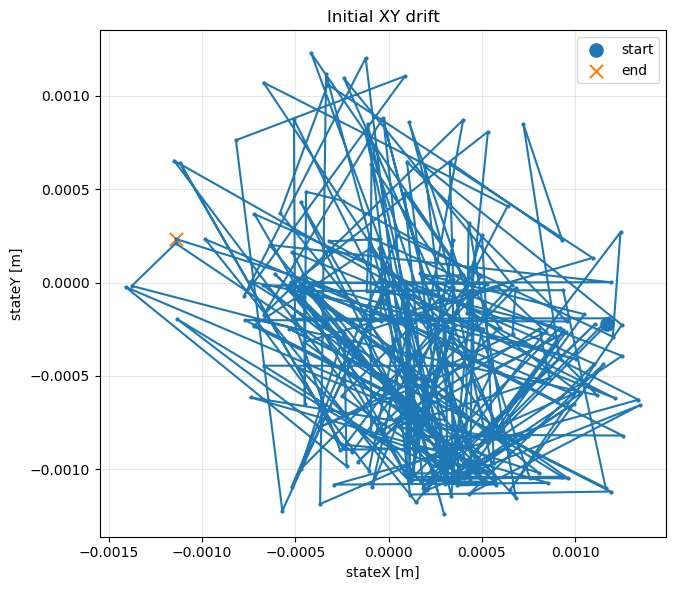

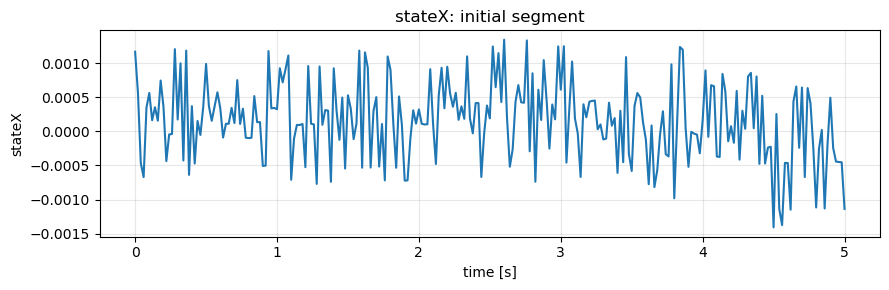

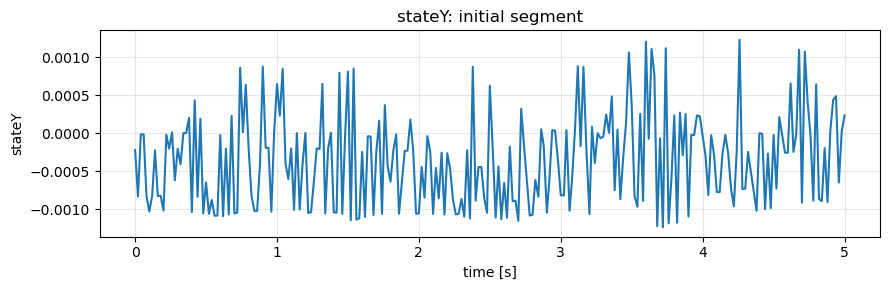

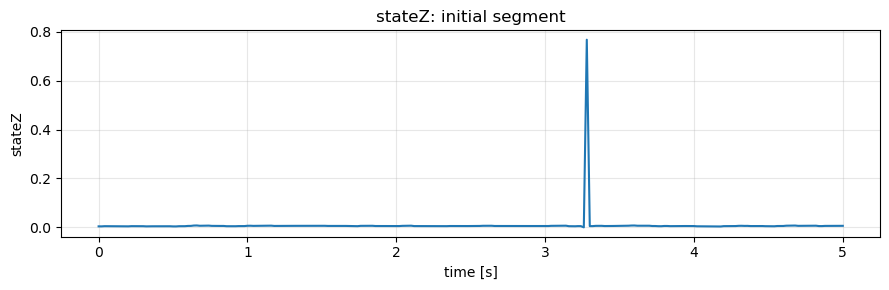

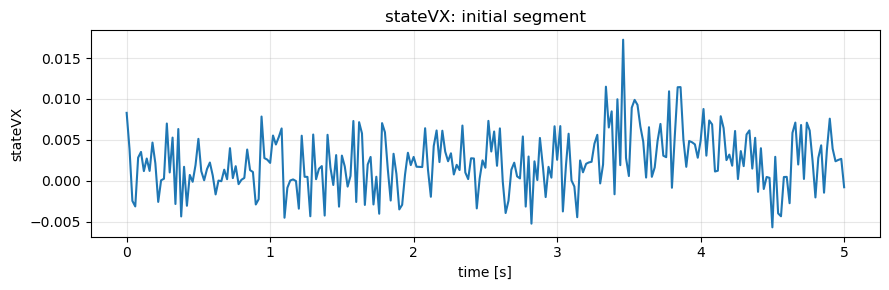

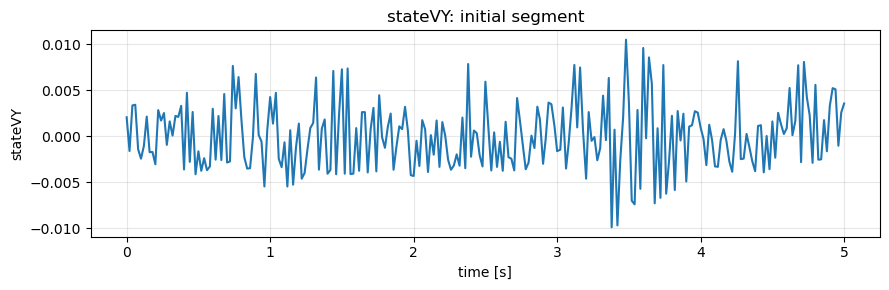

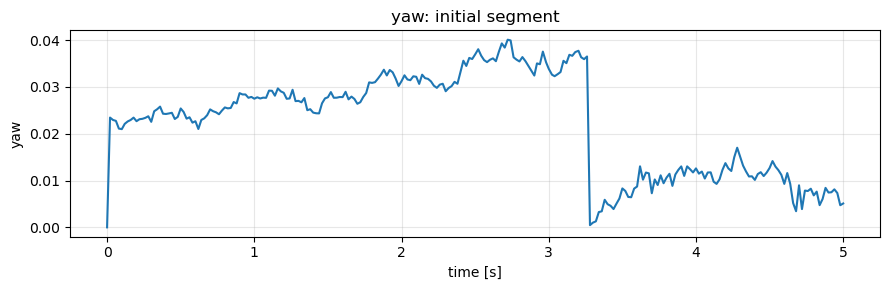

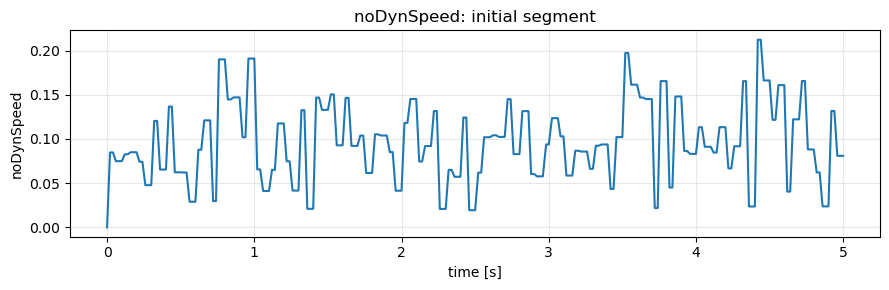

In [51]:
# Initial drift plots.
seg = first5_seg if len(first5_seg) > 2 else log_df.iloc[:min(300, len(log_df))]

if {"stateX", "stateY"}.issubset(seg.columns):
    plt.figure(figsize=(7, 6))
    plt.plot(seg["stateX"], seg["stateY"], marker="o", markersize=2)
    plt.scatter(seg["stateX"].iloc[0], seg["stateY"].iloc[0], s=90, marker="o", label="start")
    plt.scatter(seg["stateX"].iloc[-1], seg["stateY"].iloc[-1], s=90, marker="x", label="end")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.xlabel("stateX [m]")
    plt.ylabel("stateY [m]")
    plt.title("Initial XY drift")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "initial_xy_drift.png"), dpi=220)
    plt.show()

for c in ["stateX", "stateY", "stateZ", "stateVX", "stateVY", "yaw", "noDynSpeed"]:
    if c in seg.columns:
        plt.figure(figsize=(9, 3))
        plt.plot(seg["t_s"], seg[c])
        plt.grid(True, alpha=0.3)
        plt.xlabel("time [s]")
        plt.ylabel(c)
        plt.title(f"{c}: initial segment")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, f"initial_{c}.png"), dpi=220)
        plt.show()


## 3. Mission / command / trajectory columns

这里看 onboard FSM 是否切换、`cmdA/cmdB/cmdHeight` 是否改变、`trajx/trajy` 是否有效。

如果 `cmdA/cmdB` 一开始就等于 `stateX/stateY`，而 `stateX≈6`，那说明固件可能把当前 estimator 位置当成初始 hold point 了。  
如果你希望第二架从 local origin 起飞，必须在起飞前 reset estimator，使 `stateX/stateY≈0`。


In [52]:
transition_cols = [
    "t_s", "timeTick", "mission_state", "traj_index",
    "stateX", "stateY", "stateZ", "stateVX", "stateVY", "yaw",
    "cmdA", "cmdB", "cmdHeight", "contact", "trajx", "trajy"
]
transition_cols = [c for c in transition_cols if c in log_df.columns]

if "mission_state" in log_df.columns:
    print("mission_state transitions:")
    display(log_df[log_df["mission_state"].ne(log_df["mission_state"].shift())][transition_cols])
else:
    print("No mission_state column.")

if "contact" in log_df.columns:
    print("contact transitions:")
    display(log_df[log_df["contact"].ne(log_df["contact"].shift())][transition_cols])

if "traj_index" in log_df.columns:
    print("unique traj_index count:", log_df["traj_index"].nunique(dropna=True))
    print("first unique traj_index:", log_df["traj_index"].dropna().unique()[:20])


mission_state transitions:


,t_s,timeTick,mission_state,traj_index,stateX,stateY,stateZ,stateVX,stateVY,yaw,cmdA,cmdB,cmdHeight,contact,trajx,trajy
0,0.00,7462,0.0,0.0,0.001172,-0.000222,0.004065,0.008300,0.002047,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
298,5.96,13422,1.0,0.0,-0.000453,0.000179,0.004810,-0.000039,0.000890,0.014174,0.000434,-0.000037,0.3,0.0,0.0,0.0
548,10.96,18422,2.0,0.0,0.251499,-0.038408,0.354990,0.055905,0.007349,2.023311,0.000434,-0.000037,0.3,0.0,0.0,0.0
883,17.66,25122,8.0,3.0,0.169634,0.438609,0.310538,-0.112058,-0.053034,118.661209,0.138342,0.411438,0.3,0.0,0.0,0.0
936,18.72,26182,9.0,3.0,0.186693,0.456619,0.109046,0.022606,-0.056662,126.844475,0.185611,0.458101,0.3,0.0,0.0,0.0
1190,23.80,31262,NaN,NaN,0.277037,0.252838,0.000359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


contact transitions:


,t_s,timeTick,mission_state,traj_index,stateX,stateY,stateZ,stateVX,stateVY,yaw,cmdA,cmdB,cmdHeight,contact,trajx,trajy
0,0.0,7462,0.0,0.0,0.001172,-0.000222,0.004065,0.0083,0.002047,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1190,23.8,31262,NaN,NaN,0.277037,0.252838,0.000359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


unique traj_index count: 4
first unique traj_index: [0. 1. 2. 3.]


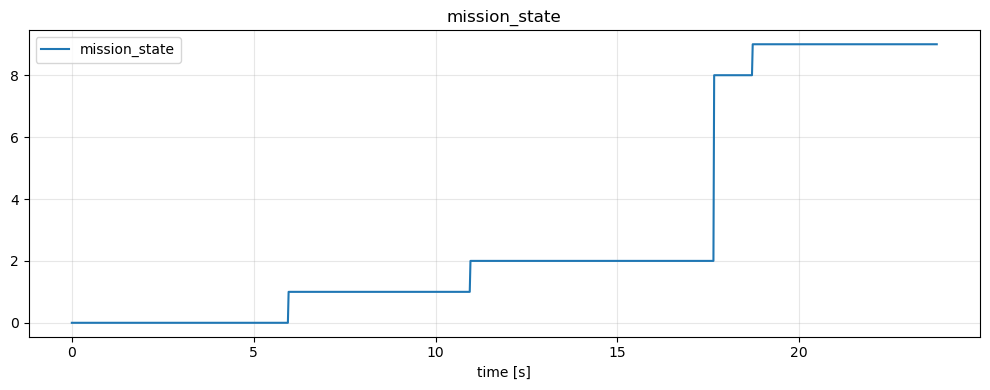

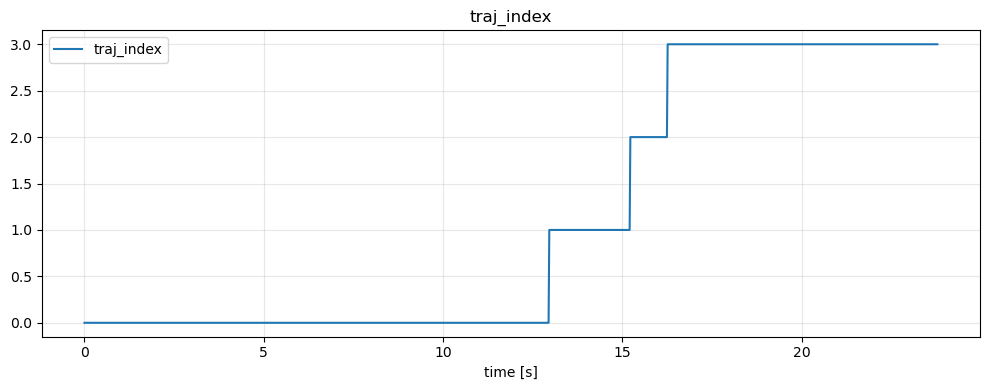

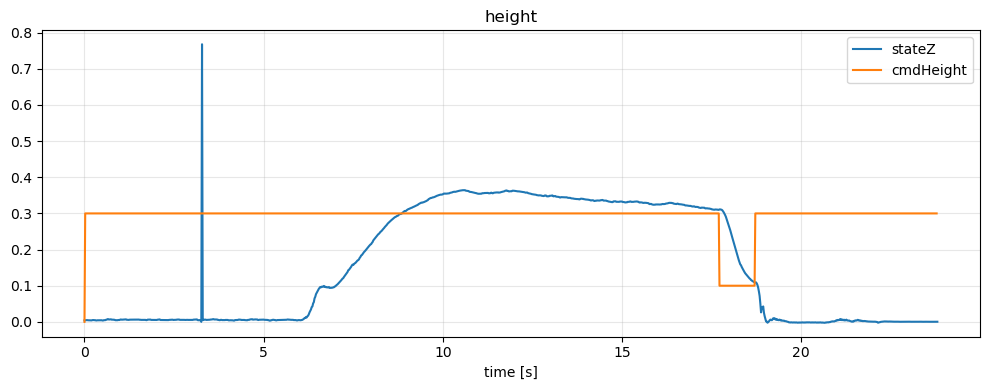

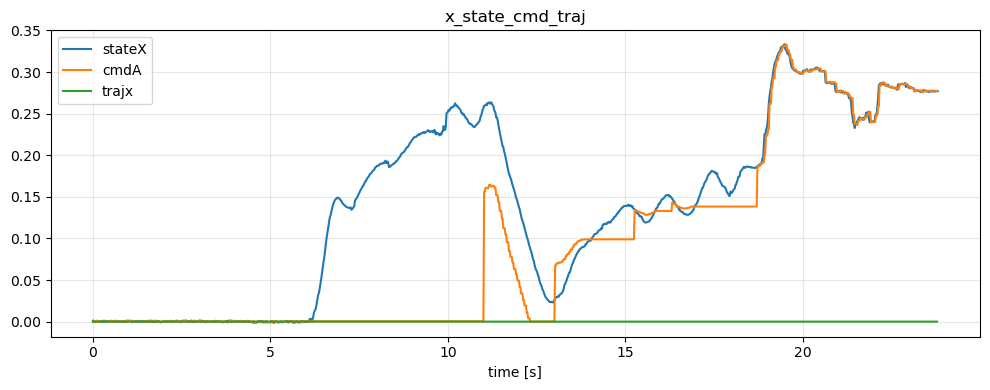

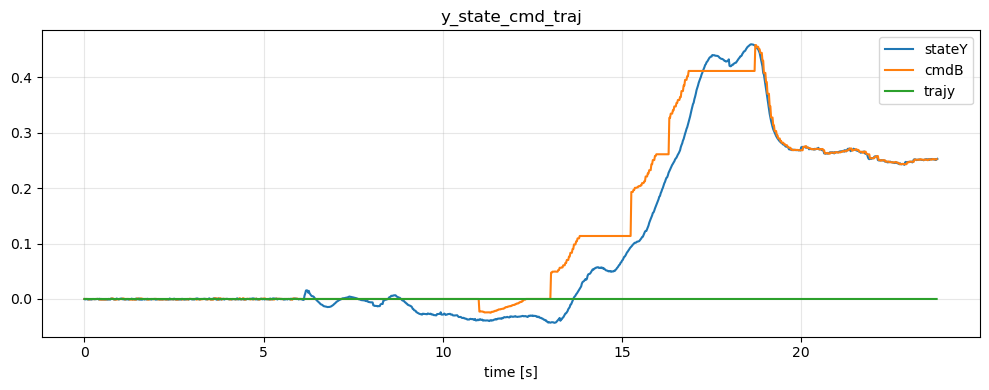

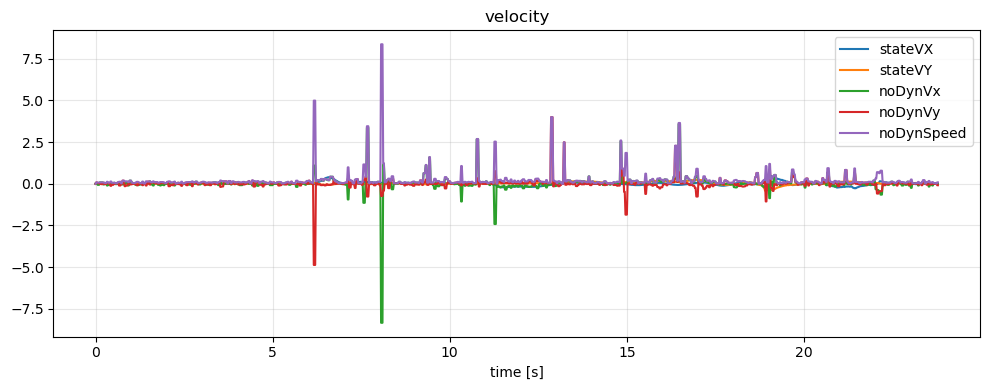

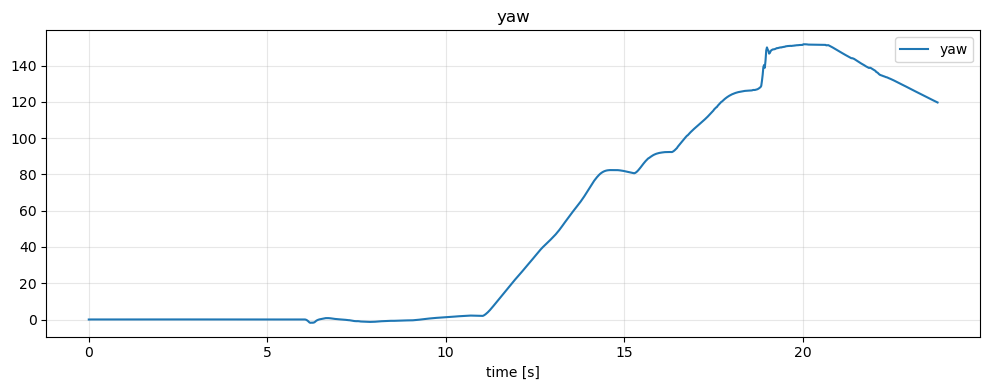

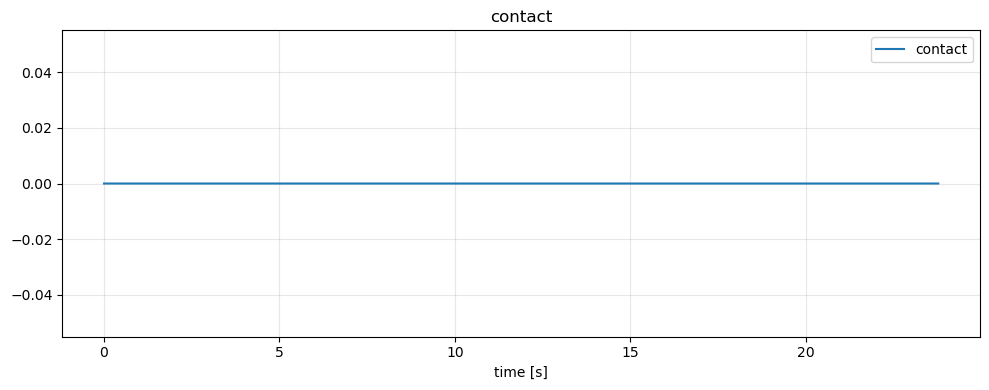

In [53]:
plot_specs = [
    ("mission_state", ["mission_state"]),
    ("traj_index", ["traj_index"]),
    ("height", ["stateZ", "cmdHeight"]),
    ("x_state_cmd_traj", ["stateX", "cmdA", "trajx"]),
    ("y_state_cmd_traj", ["stateY", "cmdB", "trajy"]),
    ("velocity", ["stateVX", "stateVY", "noDynVx", "noDynVy", "noDynSpeed"]),
    ("yaw", ["yaw"]),
    ("contact", ["contact"]),
]

for title, cols in plot_specs:
    cols = [c for c in cols if c in log_df.columns]
    if not cols:
        continue
    plt.figure(figsize=(10, 4))
    for c in cols:
        plt.plot(log_df["t_s"], log_df[c], label=c)
    plt.grid(True, alpha=0.3)
    plt.xlabel("time [s]")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{title}.png"), dpi=220)
    plt.show()


## 4. Built-in comparison using log columns

即使没有单独的 reference trajectory CSV，也可以先比较：

- `stateX/stateY`
- `cmdA/cmdB`
- `trajx/trajy`

注意：如果 estimator 一开始已经漂到 `x≈6`，绝对坐标比较会很难看。因此这里也会画一个 **start-aligned** 版本，即把 `stateX/stateY` 的第一帧减掉。


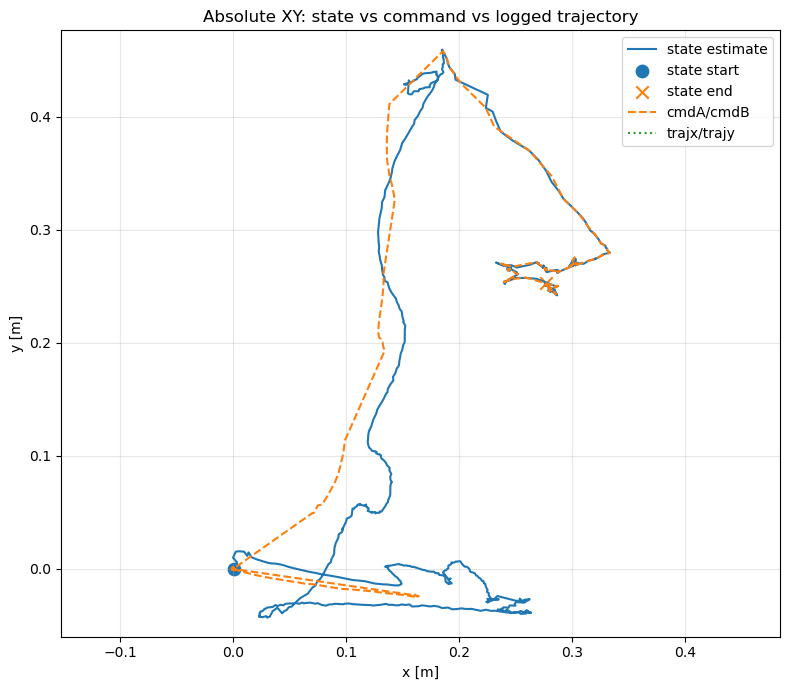

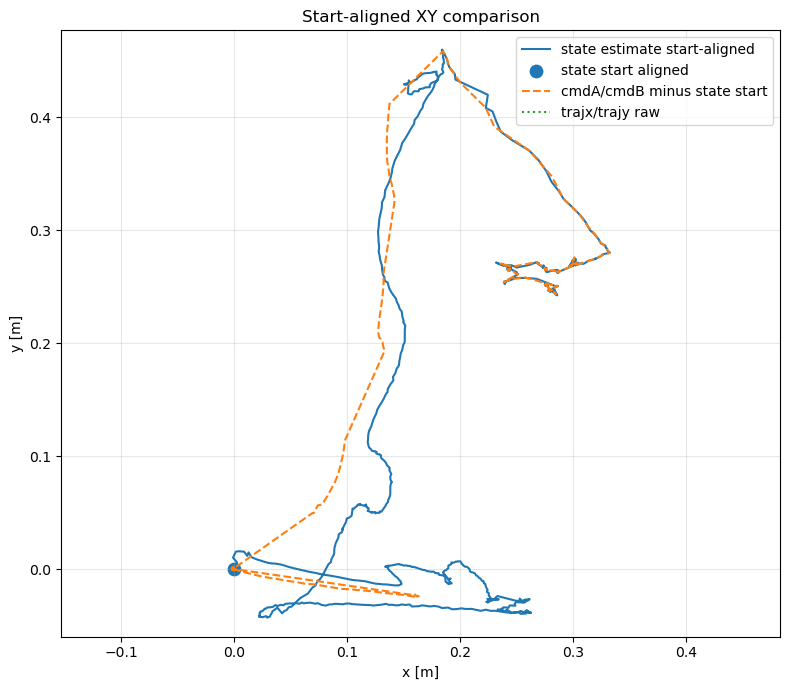

In [54]:
plt.figure(figsize=(8, 7))

if {"stateX", "stateY"}.issubset(log_df.columns):
    plt.plot(log_df["stateX"], log_df["stateY"], label="state estimate")
    plt.scatter(log_df["stateX"].iloc[0], log_df["stateY"].iloc[0], s=80, marker="o", label="state start")
    plt.scatter(log_df["stateX"].iloc[-1], log_df["stateY"].iloc[-1], s=80, marker="x", label="state end")

if {"cmdA", "cmdB"}.issubset(log_df.columns):
    plt.plot(log_df["cmdA"], log_df["cmdB"], linestyle="--", label="cmdA/cmdB")

if {"trajx", "trajy"}.issubset(log_df.columns):
    traj_valid = log_df[np.isfinite(log_df["trajx"]) & np.isfinite(log_df["trajy"])]
    if len(traj_valid) > 0:
        plt.plot(traj_valid["trajx"], traj_valid["trajy"], linestyle=":", label="trajx/trajy")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Absolute XY: state vs command vs logged trajectory")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "absolute_xy_state_cmd_traj.png"), dpi=220)
plt.show()


if COMPARE_START_ALIGNED and {"stateX", "stateY"}.issubset(log_df.columns):
    state_x0 = float(log_df["stateX"].iloc[0])
    state_y0 = float(log_df["stateY"].iloc[0])

    plt.figure(figsize=(8, 7))
    plt.plot(log_df["stateX"] - state_x0, log_df["stateY"] - state_y0, label="state estimate start-aligned")
    plt.scatter(0, 0, s=80, marker="o", label="state start aligned")

    if {"cmdA", "cmdB"}.issubset(log_df.columns):
        plt.plot(log_df["cmdA"] - state_x0, log_df["cmdB"] - state_y0, linestyle="--", label="cmdA/cmdB minus state start")

    if {"trajx", "trajy"}.issubset(log_df.columns):
        traj_valid = log_df[np.isfinite(log_df["trajx"]) & np.isfinite(log_df["trajy"])]
        if len(traj_valid) > 0:
            plt.plot(traj_valid["trajx"], traj_valid["trajy"], linestyle=":", label="trajx/trajy raw")

    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Start-aligned XY comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "start_aligned_xy_state_cmd_traj.png"), dpi=220)
    plt.show()


## 5. Optional direct comparison with your tracking trajectory table

把 `TRACK_CSV_PATH` 设成你的 trajectory CSV 路径后运行这一节。

对比逻辑：

1. 如果 reference 有时间列：按时间插值到 log 时间；
2. 如果 reference 没有时间列：按轨迹顺序重采样到 active log 段长度；
3. 同时输出 absolute error 和 start-aligned error。

如果你的 reference 是 landing-frame local trajectory，而 log estimator 没 reset 导致 `stateX≈6`，那么 **absolute error 很大但 start-aligned error 可能才有意义**。


In [55]:
def select_active_segment(df):
    # Prefer mission_state >= 1.
    if "mission_state" in df.columns and df["mission_state"].notna().any():
        active = df[df["mission_state"] >= ACTIVE_MISSION_STATE_MIN].copy()
        if len(active) > 10:
            return active.reset_index(drop=True), f"mission_state >= {ACTIVE_MISSION_STATE_MIN}"

    # Next use height.
    if "stateZ" in df.columns:
        active = df[df["stateZ"] >= ACTIVE_Z_MIN].copy()
        if len(active) > 10:
            return active.reset_index(drop=True), f"stateZ >= {ACTIVE_Z_MIN}"

    return df.copy().reset_index(drop=True), "full log"

def resample_reference_to_log(ref, active_log):
    # Determine whether reference has meaningful time.
    # If it came from pure sample index fallback, t_s will be just index*0.02; still can be used,
    # but for no-time trajectory CSV, order-based matching is usually better.
    has_time = "t_s" in ref.columns and ref["t_s"].notna().sum() > 2
    ref_out = pd.DataFrame()
    ref_out["t_s"] = active_log["t_s"].to_numpy()

    if has_time and (ref["t_s"].max() - ref["t_s"].min()) > 1e-6:
        # Normalize both to zero for comparison.
        log_t = active_log["t_s"].to_numpy()
        log_t = log_t - log_t[0]
        ref_t = ref["t_s"].to_numpy()
        ref_t = ref_t - ref_t[0]

        # If time scales are very different, fall back to order-based.
        ratio = (log_t[-1] + 1e-9) / (ref_t[-1] + 1e-9)
        if 0.2 < ratio < 5.0:
            ref_out["ref_x"] = np.interp(log_t, ref_t, ref["ref_x"].to_numpy())
            ref_out["ref_y"] = np.interp(log_t, ref_t, ref["ref_y"].to_numpy())
            if ref["ref_yaw"].notna().any():
                # unwrap before interpolation
                yaw_unwrap = np.unwrap(ref["ref_yaw"].to_numpy())
                ref_out["ref_yaw"] = wrap_to_pi(np.interp(log_t, ref_t, yaw_unwrap))
            else:
                ref_out["ref_yaw"] = np.nan
            return ref_out, "time_interpolation"

    # Order-based resampling.
    n_log = len(active_log)
    n_ref = len(ref)
    idx_ref = np.linspace(0, n_ref - 1, n_log)
    base_idx = np.arange(n_ref)

    ref_out["ref_x"] = np.interp(idx_ref, base_idx, ref["ref_x"].to_numpy())
    ref_out["ref_y"] = np.interp(idx_ref, base_idx, ref["ref_y"].to_numpy())
    if ref["ref_yaw"].notna().any():
        yaw_unwrap = np.unwrap(ref["ref_yaw"].to_numpy())
        ref_out["ref_yaw"] = wrap_to_pi(np.interp(idx_ref, base_idx, yaw_unwrap))
    else:
        ref_out["ref_yaw"] = np.nan

    return ref_out, "order_resampling"

def nearest_path_error(px, py, rx, ry, chunk=512):
    # Brute-force nearest distance with chunking; avoids requiring scipy.
    p = np.column_stack([px, py]).astype(float)
    r = np.column_stack([rx, ry]).astype(float)
    out = np.empty(len(p), dtype=float)
    nearest_idx = np.empty(len(p), dtype=int)

    for i in range(0, len(p), chunk):
        pp = p[i:i+chunk]
        d2 = ((pp[:, None, :] - r[None, :, :]) ** 2).sum(axis=2)
        idx = np.argmin(d2, axis=1)
        out[i:i+chunk] = np.sqrt(d2[np.arange(len(pp)), idx])
        nearest_idx[i:i+chunk] = idx
    return out, nearest_idx

def summarize_error(name, e):
    e = np.asarray(e, dtype=float)
    e = e[np.isfinite(e)]
    if len(e) == 0:
        return {"name": name}
    return {
        "name": name,
        "mean": float(np.mean(e)),
        "median": float(np.median(e)),
        "rmse": float(np.sqrt(np.mean(e**2))),
        "p90": float(np.percentile(e, 90)),
        "max": float(np.max(e)),
    }

if TRACK_CSV_PATH and os.path.exists(TRACK_CSV_PATH):
    ref_df, ref_time_source = load_reference(TRACK_CSV_PATH)
    active_log, active_reason = select_active_segment(log_df)

    print("TRACK_CSV_PATH:", TRACK_CSV_PATH)
    print("reference shape:", ref_df.shape)
    print("reference time source:", ref_time_source)
    print("active log:", active_reason, "rows:", len(active_log))
    display(ref_df.head())

    ref_interp, match_mode = resample_reference_to_log(ref_df, active_log)
    print("reference matching mode:", match_mode)

    comp = active_log.reset_index(drop=True).copy()
    comp = pd.concat([comp, ref_interp[["ref_x", "ref_y", "ref_yaw"]]], axis=1)

    # Absolute error.
    comp["err_x_abs"] = comp["stateX"] - comp["ref_x"]
    comp["err_y_abs"] = comp["stateY"] - comp["ref_y"]
    comp["err_xy_abs"] = np.hypot(comp["err_x_abs"], comp["err_y_abs"])

    # Start-aligned comparison.
    comp["stateX_aligned"] = comp["stateX"] - comp["stateX"].iloc[0]
    comp["stateY_aligned"] = comp["stateY"] - comp["stateY"].iloc[0]
    comp["ref_x_aligned"] = comp["ref_x"] - comp["ref_x"].iloc[0]
    comp["ref_y_aligned"] = comp["ref_y"] - comp["ref_y"].iloc[0]
    comp["err_x_aligned"] = comp["stateX_aligned"] - comp["ref_x_aligned"]
    comp["err_y_aligned"] = comp["stateY_aligned"] - comp["ref_y_aligned"]
    comp["err_xy_aligned"] = np.hypot(comp["err_x_aligned"], comp["err_y_aligned"])

    if "yaw" in comp.columns and comp["ref_yaw"].notna().any():
        comp["err_yaw"] = angle_diff(comp["yaw"], comp["ref_yaw"])
    else:
        comp["err_yaw"] = np.nan

    # Nearest path errors.
    e_nn_abs, idx_nn_abs = nearest_path_error(comp["stateX"], comp["stateY"], ref_df["ref_x"], ref_df["ref_y"])
    comp["nearest_path_err_abs"] = e_nn_abs

    e_nn_aligned, idx_nn_aligned = nearest_path_error(
        comp["stateX_aligned"], comp["stateY_aligned"],
        ref_df["ref_x"] - ref_df["ref_x"].iloc[0],
        ref_df["ref_y"] - ref_df["ref_y"].iloc[0],
    )
    comp["nearest_path_err_aligned"] = e_nn_aligned

    error_summary = pd.DataFrame([
        summarize_error("time/order matched absolute XY error", comp["err_xy_abs"]),
        summarize_error("time/order matched start-aligned XY error", comp["err_xy_aligned"]),
        summarize_error("nearest-path absolute XY error", comp["nearest_path_err_abs"]),
        summarize_error("nearest-path start-aligned XY error", comp["nearest_path_err_aligned"]),
        summarize_error("yaw error [rad]", np.abs(comp["err_yaw"])),
    ])

    print("========== Tracking error summary ==========")
    display(error_summary)

    # Save comparison table.
    comp_path = os.path.join(OUTDIR, "tracking_comparison_table.csv")
    comp.to_csv(comp_path, index=False)
    print("Saved comparison table:", comp_path)

else:
    print("TRACK_CSV_PATH is empty or file does not exist.")
    print("Set TRACK_CSV_PATH to your trajectory CSV and rerun this cell.")


TRACK_CSV_PATH: next_drone_full_trajectory_landing_frame_20260522_132342.csv
reference shape: (21, 4)
reference time source: sample_index_assumed_50Hz
active log: mission_state >= 1 rows: 892


,t_s,ref_x,ref_y,ref_yaw
0,0.00,0.000000,0.000000,0.854541
1,0.02,0.098934,0.113656,1.343438
2,0.04,0.133052,0.261125,1.535618
3,0.06,0.138342,0.411438,2.152091
4,0.08,0.055558,0.537437,-3.095038


reference matching mode: order_resampling
========== Tracking error summary ==========


,name,mean,median,rmse,p90,max
0,time/order matched absolute XY error,1.217554,1.052906,1.435232,2.352812,2.672108
1,time/order matched start-aligned XY error,1.217967,1.053391,1.435625,2.353295,2.672594
2,nearest-path absolute XY error,0.115118,0.126940,0.130081,0.192884,0.224472
3,nearest-path start-aligned XY error,0.115501,0.127312,0.130449,0.193306,0.224926
4,yaw error [rad],1.830039,1.994206,2.029748,2.903858,3.138222


Saved comparison table: crazyflie_tracking_analysis_outputs/tracking_comparison_table.csv


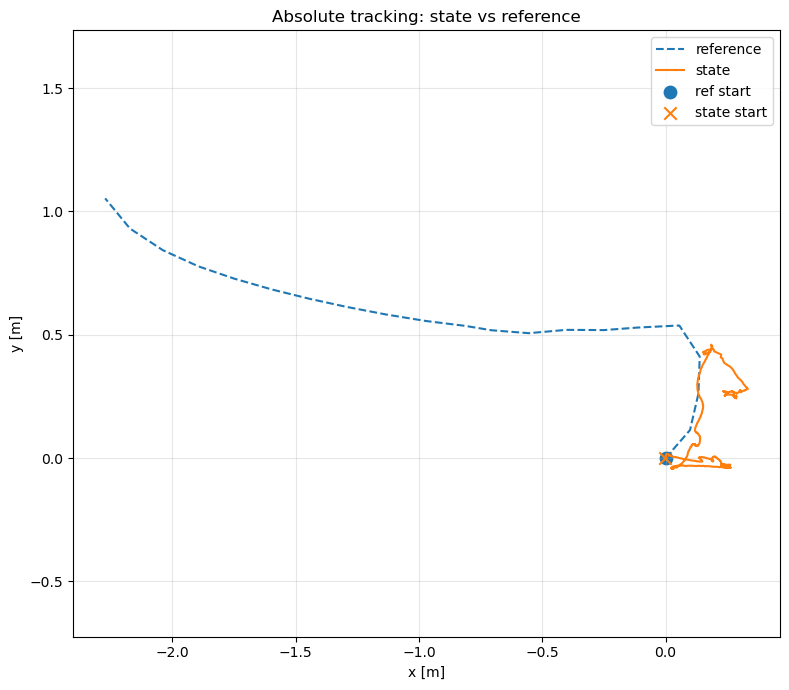

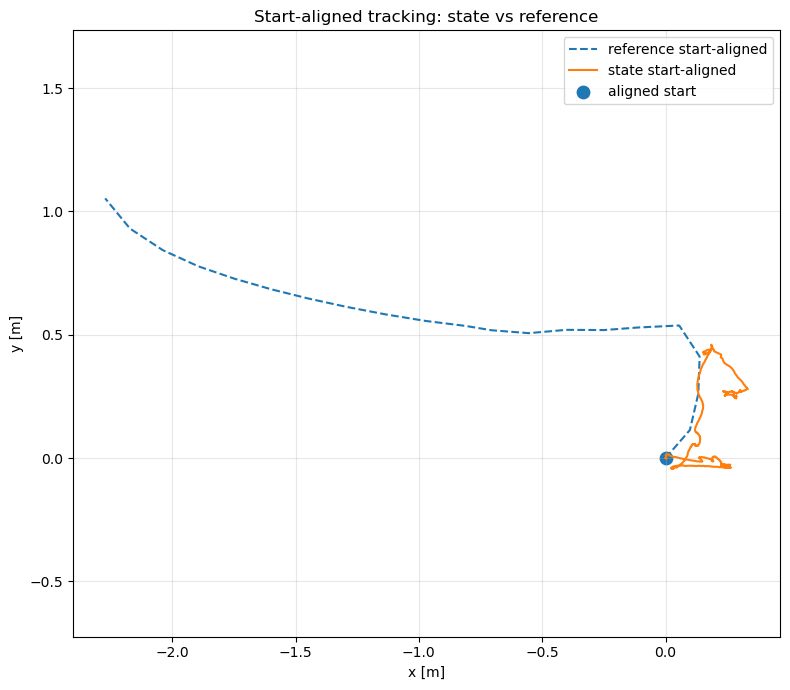

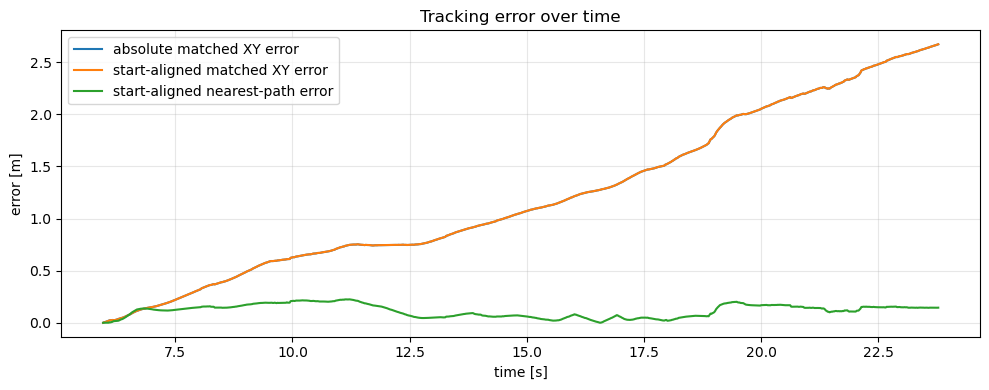

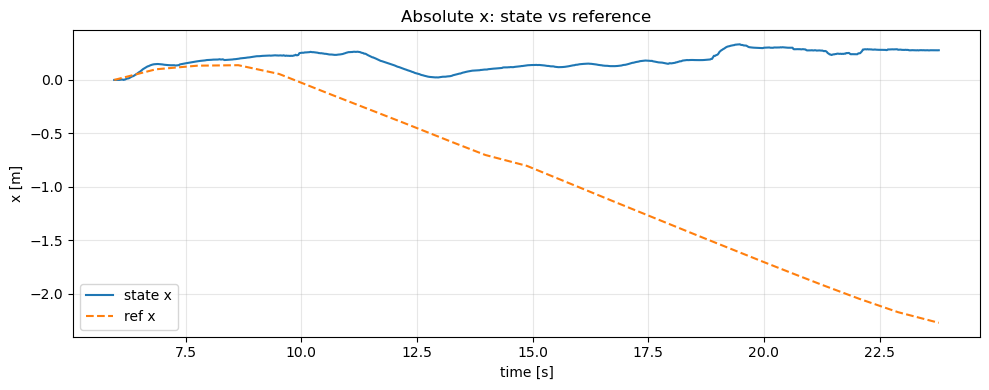

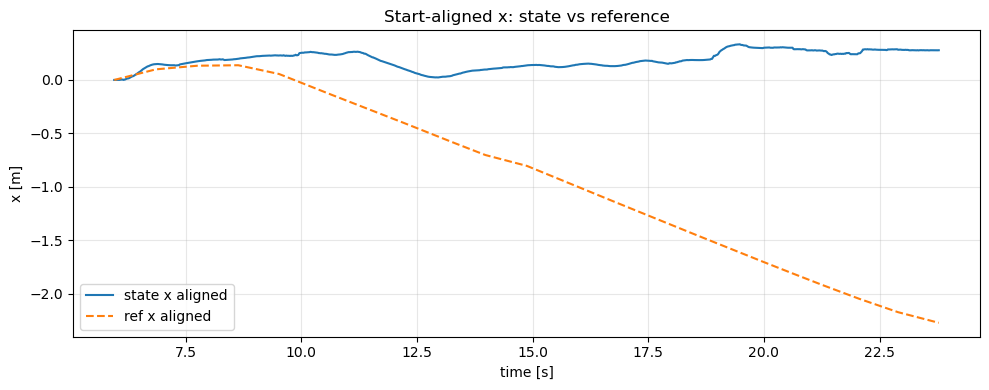

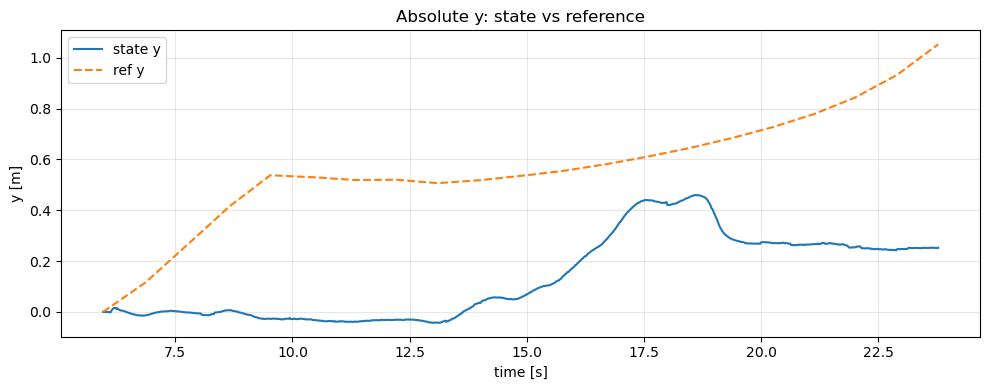

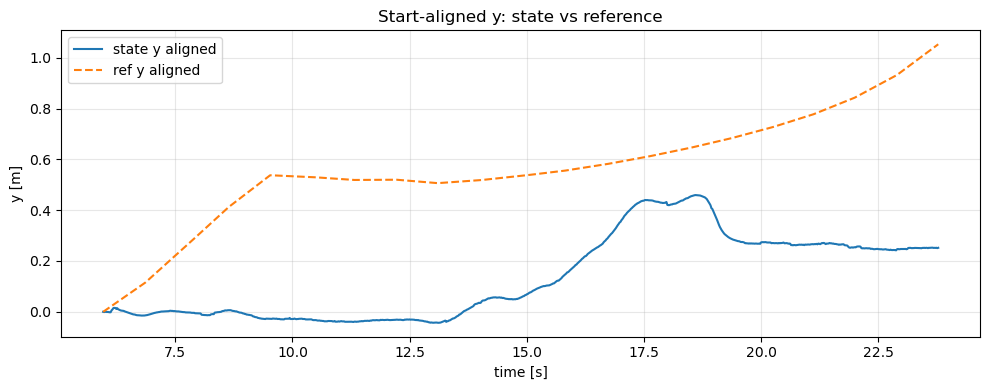

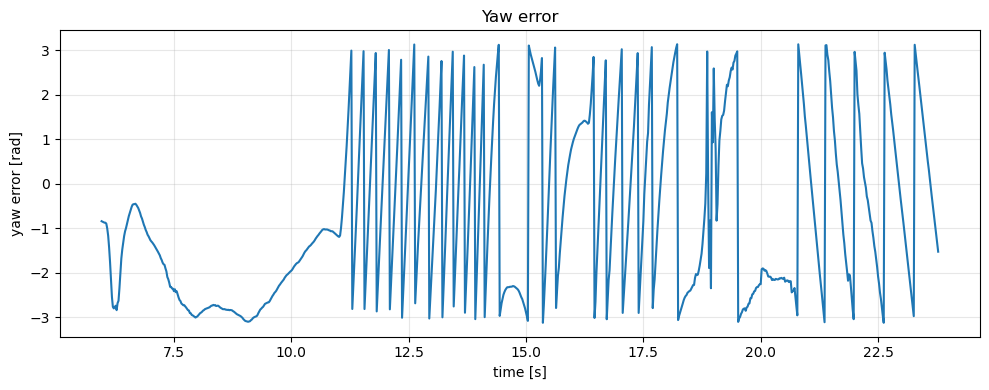

In [56]:
# Plot comparison if comp exists.
if "comp" in globals():
    # Absolute XY.
    plt.figure(figsize=(8, 7))
    plt.plot(comp["ref_x"], comp["ref_y"], "--", label="reference")
    plt.plot(comp["stateX"], comp["stateY"], label="state")
    plt.scatter(comp["ref_x"].iloc[0], comp["ref_y"].iloc[0], s=80, marker="o", label="ref start")
    plt.scatter(comp["stateX"].iloc[0], comp["stateY"].iloc[0], s=80, marker="x", label="state start")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Absolute tracking: state vs reference")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "tracking_absolute_xy.png"), dpi=220)
    plt.show()

    # Start aligned XY.
    plt.figure(figsize=(8, 7))
    plt.plot(comp["ref_x_aligned"], comp["ref_y_aligned"], "--", label="reference start-aligned")
    plt.plot(comp["stateX_aligned"], comp["stateY_aligned"], label="state start-aligned")
    plt.scatter(0, 0, s=80, marker="o", label="aligned start")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Start-aligned tracking: state vs reference")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "tracking_start_aligned_xy.png"), dpi=220)
    plt.show()

    # Error over time.
    plt.figure(figsize=(10, 4))
    plt.plot(comp["t_s"], comp["err_xy_abs"], label="absolute matched XY error")
    plt.plot(comp["t_s"], comp["err_xy_aligned"], label="start-aligned matched XY error")
    plt.plot(comp["t_s"], comp["nearest_path_err_aligned"], label="start-aligned nearest-path error")
    plt.grid(True, alpha=0.3)
    plt.xlabel("time [s]")
    plt.ylabel("error [m]")
    plt.title("Tracking error over time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "tracking_error_time.png"), dpi=220)
    plt.show()

    # X and Y over time.
    for axis in ["x", "y"]:
        state_col = f"state{axis.upper()}" if axis in ["x", "y"] else None
        ref_col = f"ref_{axis}"
        plt.figure(figsize=(10, 4))
        plt.plot(comp["t_s"], comp[state_col], label=f"state {axis}")
        plt.plot(comp["t_s"], comp[ref_col], "--", label=f"ref {axis}")
        plt.grid(True, alpha=0.3)
        plt.xlabel("time [s]")
        plt.ylabel(f"{axis} [m]")
        plt.title(f"Absolute {axis}: state vs reference")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, f"tracking_{axis}_time_absolute.png"), dpi=220)
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(comp["t_s"], comp[f"state{axis.upper()}_aligned"], label=f"state {axis} aligned")
        plt.plot(comp["t_s"], comp[f"ref_{axis}_aligned"], "--", label=f"ref {axis} aligned")
        plt.grid(True, alpha=0.3)
        plt.xlabel("time [s]")
        plt.ylabel(f"{axis} [m]")
        plt.title(f"Start-aligned {axis}: state vs reference")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, f"tracking_{axis}_time_aligned.png"), dpi=220)
        plt.show()

    # Yaw error if available.
    if comp["err_yaw"].notna().any():
        plt.figure(figsize=(10, 4))
        plt.plot(comp["t_s"], comp["err_yaw"])
        plt.grid(True, alpha=0.3)
        plt.xlabel("time [s]")
        plt.ylabel("yaw error [rad]")
        plt.title("Yaw error")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTDIR, "tracking_yaw_error.png"), dpi=220)
        plt.show()
else:
    print("No comp table. Provide TRACK_CSV_PATH and run previous cell first.")


## 6. Final diagnosis template

这一节会根据前面的结果自动给一个判断。


In [57]:
conclusions = []

if {"stateX", "stateY"}.issubset(log_df.columns):
    x0 = float(log_df["stateX"].iloc[0])
    y0 = float(log_df["stateY"].iloc[0])
    if abs(x0) > 0.3 or abs(y0) > 0.3:
        conclusions.append(f"Initial position is not near zero: stateX={x0:+.3f}, stateY={y0:+.3f}.")

if {"stateVX", "stateVY"}.issubset(log_df.columns):
    v0 = float(np.hypot(log_df["stateVX"].iloc[0], log_df["stateVY"].iloc[0]))
    if v0 > 0.2:
        conclusions.append(f"Initial velocity is large: |v|={v0:.3f} m/s.")

if len(first5_seg) > 2 and {"stateX", "stateY", "stateZ"}.issubset(first5_seg.columns):
    dx = float(first5_seg["stateX"].iloc[-1] - first5_seg["stateX"].iloc[0])
    dy = float(first5_seg["stateY"].iloc[-1] - first5_seg["stateY"].iloc[0])
    dist = float(np.hypot(dx, dy))
    z_mean = float(first5_seg["stateZ"].mean())
    if dist > 0.3 and z_mean < 0.15:
        conclusions.append(f"State moves {dist:.3f} m in first 5 seconds while mean height is only {z_mean:.3f} m.")

if "traj_index" in log_df.columns and log_df["traj_index"].nunique(dropna=True) <= 1:
    conclusions.append("traj_index does not change, so the logged trajectory index is not progressing or not being updated.")

if "contact" in log_df.columns and set(log_df["contact"].dropna().unique()) == {0.0}:
    conclusions.append("contact is always zero in this log.")

if "error_summary" in globals():
    try:
        aligned_rmse = float(error_summary.loc[error_summary["name"] == "time/order matched start-aligned XY error", "rmse"].iloc[0])
        abs_rmse = float(error_summary.loc[error_summary["name"] == "time/order matched absolute XY error", "rmse"].iloc[0])
        conclusions.append(f"Tracking RMSE: absolute={abs_rmse:.3f} m, start-aligned={aligned_rmse:.3f} m.")
        if abs_rmse > aligned_rmse * 2:
            conclusions.append("Absolute tracking error is much larger than start-aligned error, suggesting a global estimator offset.")
    except Exception:
        pass

print("========== Conclusions ==========")
for i, c in enumerate(conclusions, 1):
    print(f"{i}. {c}")

print("\nRecommended actions:")
print("1. Before arming, call kalman.resetEstimation and wait until stateX/stateY/stateVX/stateVY are near zero.")
print("2. If using custom estimator states such as noDyn/wof/wf, verify they are also reset when kalman.resetEstimation is triggered.")
print("3. For second-drone local trajectory tracking, physically place the drone at the landing-frame origin and reset estimator there.")
print("4. Then compare the trajectory using the start-aligned plots; if start-aligned error is good but absolute error is bad, the issue is frame/estimator initialization.")


========== Conclusions ==========
1. contact is always zero in this log.
2. Tracking RMSE: absolute=1.435 m, start-aligned=1.436 m.

Recommended actions:
1. Before arming, call kalman.resetEstimation and wait until stateX/stateY/stateVX/stateVY are near zero.
2. If using custom estimator states such as noDyn/wof/wf, verify they are also reset when kalman.resetEstimation is triggered.
3. For second-drone local trajectory tracking, physically place the drone at the landing-frame origin and reset estimator there.
4. Then compare the trajectory using the start-aligned plots; if start-aligned error is good but absolute error is bad, the issue is frame/estimator initialization.
